## Configuracao e carga dos dados

In [0]:
# Análise Exploratória de Dados (EDA)
# Exploração visual da Camada Ouro utilizando Python (Pandas/Seaborn).
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

print("Carregando a Tabela Ouro de Lucratividade...")
df_ouro = spark.table("lh_nautical.lh_nautical_db.gld_lucro_detalhado").toPandas()
print(f"Dados carregados com sucesso! Total de registros: {len(df_ouro)}")

Carregando a Tabela Ouro de Lucratividade...
Dados carregados com sucesso! Total de registros: 9895


## Visao geral - lucro categoria

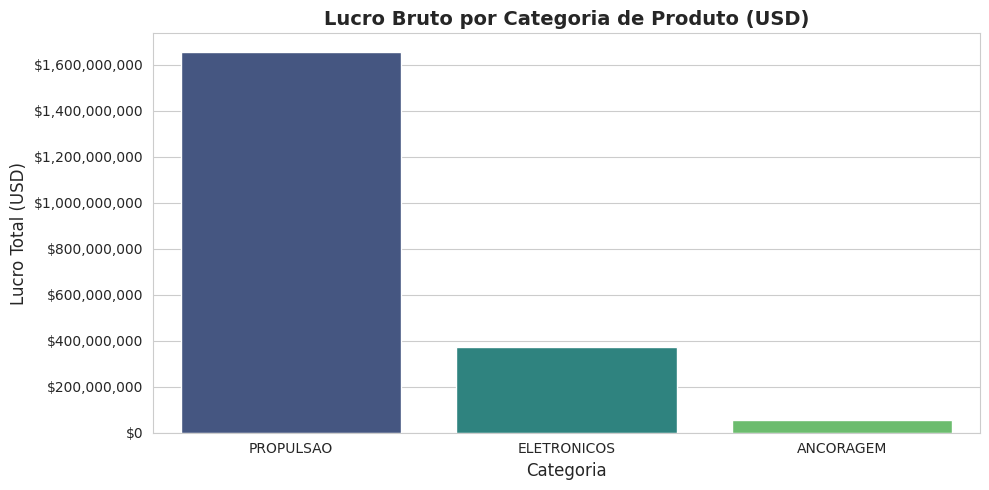

In [0]:
# Lucro Bruto por Categoria de Produto
# ==============================================================================
df_categoria = df_ouro.groupby('product_category')['gross_profit'].sum().reset_index()
df_categoria = df_categoria.sort_values(by='gross_profit', ascending=False)

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
grafico = sns.barplot(data=df_categoria, x='product_category', y='gross_profit', hue='product_category', palette='viridis', legend=False)

plt.title('Lucro Bruto por Categoria de Produto (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Lucro Total (USD)', fontsize=12)

formatter = ticker.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## Top Clientes vs Piores produtos

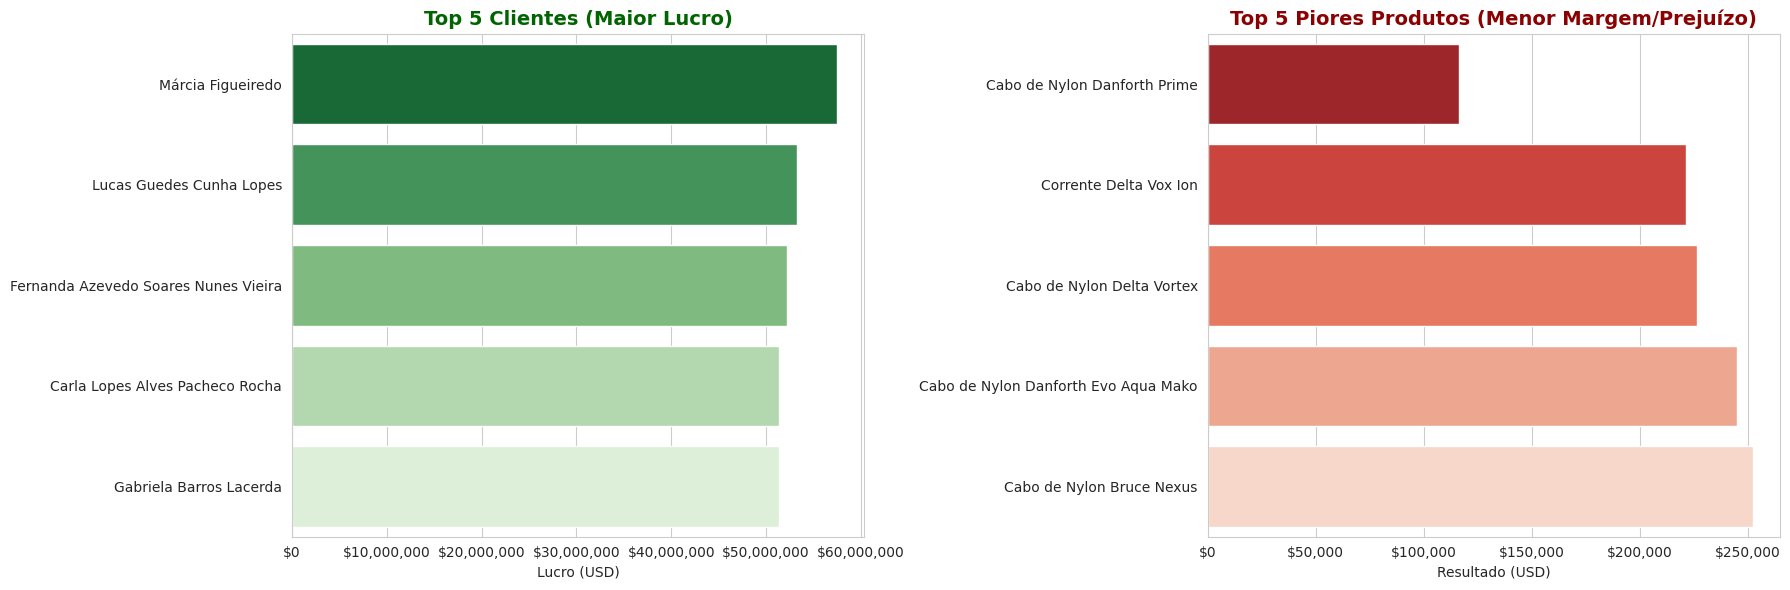

In [0]:
# Análise de Extremos (Melhores Clientes e Piores Margens)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Cria 2 gráficos lado a lado

df_clientes = df_ouro.groupby('client_name')['gross_profit'].sum().reset_index().sort_values(by='gross_profit', ascending=False).head(5)
sns.barplot(ax=axes[0], data=df_clientes, x='gross_profit', y='client_name', hue='client_name', palette='Greens_r', legend=False)
axes[0].set_title('Top 5 Clientes (Maior Lucro)', fontsize=14, fontweight='bold', color='darkgreen')
axes[0].set_xlabel('Lucro (USD)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

df_piores = df_ouro.groupby('product_name')['gross_profit'].sum().reset_index().sort_values(by='gross_profit', ascending=True).head(5)
sns.barplot(ax=axes[1], data=df_piores, x='gross_profit', y='product_name', hue='product_name', palette='Reds_r', legend=False)
axes[1].set_title('Top 5 Piores Produtos (Menor Margem/Prejuízo)', fontsize=14, fontweight='bold', color='darkred')
axes[1].set_xlabel('Resultado (USD)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()